In [21]:
# read h5 file and plot figures

import os
import numpy as np
import h5py
import matplotlib.pyplot as plt

# test_data_path="G:/云南巧家宽频带数据/hdf5_merged"
# file_list = [file for file in os.listdir(test_data_path) if ".hdf5" in file]
# print(file_list[0])

# def read_h5(path):
#     """
#     read .h5 file and convert to ndarray
#     Args:
#         path: data path

#     Returns:

#     """
#     f = h5py.File(path, "r")
#     data = f["/earthquake/"]['QJ.QJ02.20220824.040010']
#     # group_names = f["/earthquake"].keys()
#     # for group_name in group_names:
#     #     print(group_name)
#     #     ipdb.set_trace ()
#     #     data = f["/earthquake/"][group_name]
        
    
#     return np.array(data)

# data= read_h5(os.path.join(test_data_path,file_list[0]))
# print(data)

file_path = "G:/云南巧家宽频带数据/denoised_h5/QJ022022_denoised.hdf5"
# 定义函数用于从 HDF5 文件中读取数据
def read_hdf5_file(file_name):
    with h5py.File(file_name, 'r') as hdf5_file:
    #data = hdf5_file[dataset_name][()]
    #ipdb.set_trace()
        group_name = hdf5_file.keys()
        print(group_name)
        dataset = hdf5_file['earthquake']['15']
        data = np.array(dataset)
    return data



# 读取数据集
waveform_data = read_hdf5_file(file_path)
print(waveform_data.shape)
# 绘制波形图
fig = plt.figure(figsize=(10, 1.8))
plt.plot(waveform_data[:,0],  color='#1f77b4')
#plt.plot(waveform_data[:,1],  color='k')
#plt.plot(waveform_data[:,2],  color='w')
plt.show()

OSError: Unable to open file (truncated file: eof = 593327504, sblock->base_addr = 0, stored_eof = 593567504)

In [ ]:
import h5py
import numpy as np

def list_hdf5_groups(hdf5_file):
    """ list of group names of hdf5 file"""

    wave_ids = []


    group_list = hdf5_file['earthquake'].keys()

    for wave_id in group_list:
        wave_ids.append(wave_id)
    return wave_ids
fl = h5py.File("G:/云南巧家宽频带数据/denoised_h5/QJ022022_denoised.hdf5", 'r')
prediction_list = list_hdf5_groups(fl)
print(prediction_list[:10])
# 200s
from obspy import UTCDateTime
# 示例波形 ID
waveform_id = prediction_list[0]

# 提取开始日期和时间

station, station_id, date_str, time_str = waveform_id.split(".")
month_str = time_str[:2]
counts = int(time_str[2:])
print(counts)
start_time_str = f"{date_str[:4]}/{date_str[4:6]}/{date_str[6:]} {month_str}:00:00"

# 计算开始和结束时间
P_pred = 5834
start_time = UTCDateTime(start_time_str)
waveform_duration = 200  # 每段波形时长 200 秒
end_time = start_time + waveform_duration*counts
end_time = end_time+P_pred/100

# 打印结果
print(f"开始时间: {start_time}")  # UTCDateTime("2022-08-23T09:00:00Z")
print(f"结束时间: {end_time}")    # UTCDateTime("2022-08-23T09:03:20Z")


['QJ.QJ02.20220823.090001', 'QJ.QJ02.20220823.090002', 'QJ.QJ02.20220823.090003', 'QJ.QJ02.20220823.090004', 'QJ.QJ02.20220823.090005', 'QJ.QJ02.20220823.090006', 'QJ.QJ02.20220823.100007', 'QJ.QJ02.20220823.100008', 'QJ.QJ02.20220823.100009', 'QJ.QJ02.20220823.100010']
51465
开始时间: 2022-12-20T12:00:00.000000Z
结束时间: 2023-04-18T15:10:58.340000Z


In [27]:
from os import listdir
station_list = [ev.split(".")[0] for ev in listdir("G:/云南巧家宽频带数据/denoised_h5/") ];  # input_dir = ../hdf5_merged     station_list=[QJ01,QJ02,...,QJ10]
station_list = sorted(set(station_list))   # set去重，sort默认升序排列
print(station_list)
for ct, st in enumerate(station_list[1:2]):
            # # st = QJ01
            print(ct,st)

['QJ01202208_denoised', 'QJ022022_denoised', 'QJ022023_denoised', 'QJ032022_denoised']
0 QJ022022_denoised


In [ ]:
## 将多个picks文件合成为一个总picks文件，并存到gammaAssociation
import os
import pandas as pd

# 定义包含多个 CSV 文件的文件夹路径
output_file = "D:/MyRepository/Qiaojia/GammaAssociation/merged_output.csv"  # 合并后的文件路径

# 获取文件夹中的所有 CSV 文件
csv_files = ['D:/MyRepository/detect4asso4QJ_denoised_finalmodel/QJ01202208_denoised_outputs/picks_results.csv','D:/MyRepository/detect4asso4QJ_denoised_finalmodel/QJ022022_denoised_outputs/picks_results.csv','D:/MyRepository/detect4asso4QJ_denoised_finalmodel/QJ022023_denoised_outputs/picks_results.csv','D:/MyRepository/detect4asso4QJ_denoised_finalmodel/QJ032022_denoised_outputs/picks_results.csv'  ]

# 定义统一的列顺序
expected_columns = ["station_id", "waveform_id", "phase_time", "phase_type", "phase_score", "phase_amplitude"]

# 初始化一个空的 DataFrame
merged_df = pd.DataFrame()

# 逐个读取并合并文件
for csv_file in csv_files:
    
    df = pd.read_csv(csv_file,index_col=False)  # 读取当前文件
    # 去掉列名空格并调整列顺序
    df.columns = df.columns.str.strip()
    df = df[expected_columns]  # 调整列顺序
    # 修改 station_id 列，提取前四个字符
    df["station_id"] = df["station_id"].str.extract(r"^(QJ\d{2})")  # 提取格式类似 QJ02 的部分
    merged_df = pd.concat([merged_df, df], ignore_index=True)  # 合并

# 将合并后的数据保存为新的 CSV 文件
merged_df.to_csv(output_file, index=False)
print(f"合并完成，保存到: {output_file}")




合并完成，保存到: D:/MyRepository/Qiaojia/GammaAssociation/merged_output.csv


In [49]:
# 读取文件
output_file = "D:/MyRepository/Qiaojia/GammaAssociation/merged_output.csv"  # 合并后的文件路径
df = pd.read_csv(output_file)
df = df.dropna()
df = df[(df != 0).all(axis=1)]  # 删除含有 0 的行

# 检查是否存在所需的列
if "phase_time" in df.columns and "phase_score" in df.columns:
    # 1. 修改 phase_time 列格式
    try:
        df["phase_time"] = pd.to_datetime(df["phase_time"])  # 转换为 datetime 对象
        df["phase_time"] = df["phase_time"].dt.strftime("%Y-%m-%d %H:%M:%S.%f").str[:-3]  # 转换为目标格式
    except Exception as e:
        print(f"无法解析 phase_time 列，请检查数据格式是否正确: {e}")

    # 2. 归一化 phase_score 列
    try:
        min_score = df["phase_score"].min()
        max_score = df["phase_score"].max()
        if max_score > min_score:  # 确保有范围
            df["phase_score"] = (df["phase_score"] - min_score) / (max_score - min_score)
        else:
            print("phase_score 列中所有值相同，无法归一化。")
    except Exception as e:
        print(f"无法处理 phase_score 列，请检查数据格式是否正确: {e}")

    df = df[df["phase_score"] != 0]
    # 保存回原文件
    df.to_csv(output_file, index=False)
    print(f"处理完成，结果已保存到 {output_file}")
else:
    missing_columns = [col for col in ["phase_time", "phase_score"] if col not in df.columns]
    print(f"文件中缺少以下列：{missing_columns}")

处理完成，结果已保存到 D:/MyRepository/Qiaojia/GammaAssociation/merged_output.csv


In [47]:
import pandas as pd

# 加载 CSV 文件
file_path = "D:\MyRepository\Qiaojia\AssResults\picks_gamma.csv"  # 替换为你的文件路径
df = pd.read_csv(file_path,sep='\t')
print(df.columns)

# 检查 prob 列是否存在
if "prob" in df.columns:
    # 检查并处理无效值
    if df["prob"].isnull().any() or (df["prob"] <= 0.0).any():
        print("发现无效的 prob 值（空值或非正数）。将跳过这些行的计算。")
        # 替换空值和小于等于 0 的值为 NaN
        df["prob"] = df["prob"].where(df["prob"] > 0)
    
    # 计算 log(prob)
    df["log_prob"] = np.log(df["prob"])
    
    # 检查结果
    print("添加了 log_prob 列。")
    print(df.head())
    
    # 保存结果到新的 CSV 文件
    output_path = "pick_gamma_with_log_prob.csv"
    df.to_csv(output_path, sep="\t", index=False)
    print(f"结果已保存到 {output_path}")
else:
    print("文件中没有 'prob' 列。")


Index(['id', 'timestamp', 'type', 'prob', 'amp', 'event_idx', 'prob_gamma'], dtype='object')
添加了 log_prob 列。
     id                   timestamp type   prob          amp  event_idx  \
0  QJ02  2022-08-23T09:04:04.590000    S  0.001  5522.204102         -1   
1  QJ02  2022-08-23T09:06:39.990000    P  0.002    24.092178         -1   
2  QJ02  2022-08-23T09:09:59.990000    P  0.003    48.796562         -1   
3  QJ02  2022-08-23T09:09:59.990000    S  0.002    48.796562         -1   
4  QJ02  2022-08-23T09:13:19.990000    P  0.081   323.997650         -1   

   prob_gamma  log_prob  
0          -1 -6.907755  
1          -1 -6.214608  
2          -1 -5.809143  
3          -1 -6.214608  
4          -1 -2.513306  
结果已保存到 pick_gamma_with_log_prob.csv


In [57]:
import multiprocessing as mp
print(mp.cpu_count()-1)
unique_labels = [0]
print(len(unique_labels))
print(min(len(unique_labels) // 4))
ncpu = max(1, min(len(unique_labels) // 4, min(32, mp.cpu_count() - 1)))
print(ncpu)

19
1


TypeError: 'int' object is not iterable

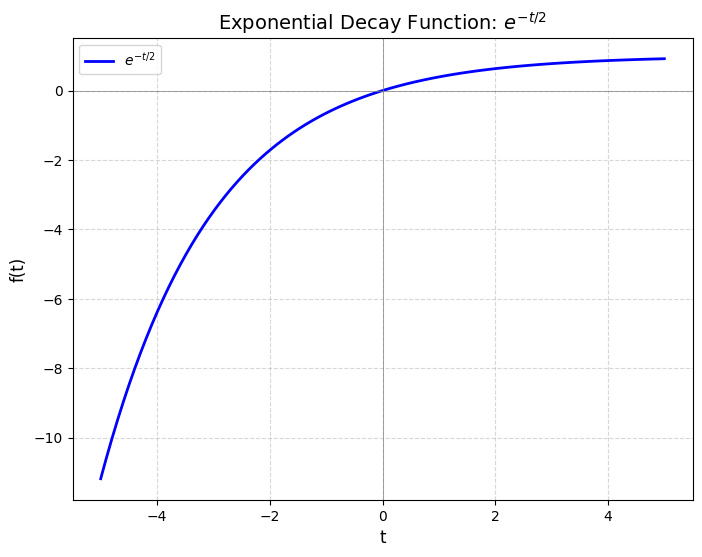

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 定义时间变量 t 范围
t = np.linspace(-5, 5, 100)  # 从 -10 到 10，分成 500 个点

# 定义函数 e^(-t/2)
y = 1-np.exp(-t / 2)

# 绘制曲线
plt.figure(figsize=(8, 6))
plt.plot(t, y, label=r'$e^{-t/2}$', color='b', linewidth=2)

# 添加图形标题和坐标轴标签
plt.title('Exponential Decay Function: $e^{-t/2}$', fontsize=14)
plt.xlabel('t', fontsize=12)
plt.ylabel('f(t)', fontsize=12)

# 添加网格、图例和坐标轴
plt.axhline(0, color='gray', linewidth=0.5)  # 添加 x 轴
plt.axvline(0, color='gray', linewidth=0.5)  # 添加 y 轴
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# 显示图像
plt.show()
